# Do borrowed ideas stick when grafted locally? RQ2-D2 host-entry test (demo)

This notebook is a runnable walkthrough of the **RQ2-D2 host-entry experiment** from the study *"Occupancy is not integration"*, which looks at how emerging scientific concepts diffuse across disciplines in an evolving OpenAlex knowledge network.

**The question.** A concept `c` born in an origin subfield `o` first appears in a new *host* subfield `d` in year `e` (a *host entry*). Does the entry take hold, meaning newcomers keep publishing on `c` in `d` over the next five years? Two mechanisms compete:

| Mechanism | Measure (computed from the entry-year `d` papers) | Reading if it predicts uptake |
|---|---|---|
| **Grafting / anchoring** | `A_cont`: the partner concepts' pre-entry *host share*, i.e. how native they already are to `d` | **GRAFTING** |
| **Co-transfer / toolkit** | `CT`: the share of partners that were already `c`'s companions in the origin subfield in `[e-5, e-1]` | **TOOLKIT** |

**Outcome.** `Y_strict` counts the host papers on `c` in `W2 = [e+1, e+5]` whose authors are disjoint from everyone who had worked on `c` before (author-disjoint newcomers).

**Estimator.** PPML (Poisson pseudo-ML) with high-dimensional fixed effects, the offset `log(n_entry_papers)`, and concept-clustered CRV1 standard errors, plus a wild cluster score bootstrap. A pre-registered Holm rule over `{b_A, b_CT}` decides GRAFTING / TOOLKIT / BOTH / NEITHER.

**What this demo runs.** The original `method.py` runs 17 stages. Stages 1–6 build the event table from a multi-GB hydrated OpenAlex corpus, which is too large to ship. The demo therefore starts from the **stage-6 output** (`screen_events_with_outcomes.parquet`, one row per host-entry event, with W1 features and W2 outcomes) and runs the original code for:

* **stage 6 (tail):** the outcome-sparsity decision;
* **stage 7:** the PPML models (primary, co-primary secondary, and pre-declared alternative FE specs), the Holm decision, and the fallback-3 thin-cell rule;
* **stage 9 (part):** the within-cell label-shuffle placebo. The nativeness-permutation placebo needs the raw subfield profiles of every partner node, so it is not included;
* **stage 12:** the grouped-by-concept out-of-sample predictive check.

**Demo data.** `mini_demo_data.json` holds **100 of the 1,740** screen MAIN kw5 events (56 concepts). They were chosen *structurally*, never on outcomes: events in the three most frequent host subfields, whole concepts added in ID order. The file also stores the full-run reference numbers so the final cell can compare against them. With only 100 events, the primary `concept x e + d x e` spec has too few non-singleton cells and gets pruned away. That is an extreme version of what happened in the full run, where it kept only 26% of events and triggered the pre-declared *fallback 3*, making the `concept + e + d` spec co-primary. The demo estimates are therefore illustrative and noisy. The headline numbers are the full-run references shown at the end.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0',
         'polars==1.31.0', 'pyarrow==18.1.0', 'seaborn==0.13.2', 'tqdm==4.67.3', 'tabulate==0.9.0', 'lxml==6.0.2')

# Packages NOT pre-installed on Colab (always install everywhere)
_pip('loguru==0.7.3', 'pyfixest==0.60.0')

## Imports
These are the original import blocks of `method.py`, `src/ppml.py`, `src/models.py` and `src/assemble_out.py`, plus `matplotlib` for the final figure.

In [2]:
from __future__ import annotations

import hashlib
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import PoissonRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import matplotlib.pyplot as plt  # notebook addition: final visualization

## Load the demo data
The notebook tries the GitHub raw URL first and falls back to a local `mini_demo_data.json`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/main/round-3/experiment-7/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
# The event table replaces pd.read_parquet(RESULTS / "screen_events_with_outcomes.parquet") (stage-6 output)
df = pd.DataFrame(data["events"])
REF = data["metadata"]["full_run_reference"]  # full-run (1,740-event) numbers, used only for comparison at the end
print(df.shape, "events x columns;", df.concept_id.nunique(), "concepts;", "host subfields d:", sorted(df.d.unique()))
print(data["metadata"]["selection"])
df[["concept_id", "o", "d", "e", "n_entry_papers", "A_cont", "CT", "Y_strict", "Y_lenient", "Y_all", "field_group"]].head()

(100, 83) events x columns; 56 concepts; host subfields d: [np.int64(1702), np.int64(2204), np.int64(2208)]
Selection (structural only, never on outcomes): screen fold, MAIN, kw5, main arm, complete controls (= the models.primary_sample rows). Keep events whose host subfield d is one of the N_HOSTS most frequent host subfields (so the d fixed effect is identified), then add whole concepts in concept-id order while the total stays <= N_MAX.


,concept_id,o,d,e,n_entry_papers,A_cont,CT,Y_strict,Y_lenient,Y_all,field_group
0,c_007a7950eb4d,2613,2208,2009,1,0.045877,0.333333,1,1,1,other
1,c_007a7950eb4d,2613,1702,2011,1,0.084133,0.181818,2,2,3,other
2,c_007a7950eb4d,2613,2204,2018,1,0.042967,0.125000,1,1,1,other
3,c_015399b04dea,3109,2208,2011,1,0.055975,0.700000,0,0,0,Physics/Astro
4,c_02792d2208de,1703,2208,2012,1,0.036124,0.400000,0,0,0,CS


## Configuration
All tunable parameters are here. `SEED` is the frozen value from `src/config.py`. The comments give the original full-run values; the demo uses them because all 100 events fit in a few seconds per fit.

In [5]:
SEED = 20260929        # config.SEED (part of the frozen pre-registration)
WILD_REPS = 999        # wild cluster (Rademacher) score-bootstrap reps per tested coefficient (original: 999)
LABEL_SHUFFLES = 50    # within-cell Y_strict label-shuffle placebo draws (original: 50)
OOS_BOOT_REPS = 1000   # concept-cluster bootstrap reps for the out-of-sample deviance CI (original: 1000)
OOS_FOLDS = 5          # grouped-by-concept folds, int(sha1(concept_id), 16) % 5 (original: 5)
PPML_MAXIT = 500       # IRLS iterations in models.fit_one (original: 500)
PPML_TOL = 1e-12       # IRLS relative deviance tolerance in models.fit_one (original: 1e-12)

# Notebook replacement for config.RESULTS: outputs are written to ./results
RESULTS = Path("results")
RESULTS.mkdir(parents=True, exist_ok=True)

## Stage 6 (tail): outcome-sparsity decision
From `method.py`, stage 6: before any coefficient is estimated, the pre-declared rule switches the primary outcome to `Y_lenient` if more than 85% of the primary sample has `Y_strict = 0`. The full run found a 36% zero share, so `Y_strict` stays primary.

In [6]:
out = df
p = out[out.MAIN & out.kw5]
dec = {"n_primary_sample": int(len(p)), "Y_strict_zero_share": float((p.Y_strict == 0).mean()),
       "Y_lenient_zero_share": float((p.Y_lenient == 0).mean()),
       "Y_all_zero_share": float((p.Y_all == 0).mean()),
       "rule": "switch primary to Y_lenient iff Y_strict zero share > 0.85 (decided before any coefficient)"}
dec["switch_to_lenient"] = dec["Y_strict_zero_share"] > 0.85
(RESULTS / "outcome_sparsity_decision.json").write_text(json.dumps(dec, indent=1))
dec

{'n_primary_sample': 100,
 'Y_strict_zero_share': 0.34,
 'Y_lenient_zero_share': 0.31,
 'Y_all_zero_share': 0.29,
 'rule': 'switch primary to Y_lenient iff Y_strict zero share > 0.85 (decided before any coefficient)',
 'switch_to_lenient': False}

## The PPML estimator (`src/ppml.py`)
This is a fast Poisson pseudo-ML with several high-dimensional fixed effects. The pieces are:

* `_prune` iteratively drops singleton FE levels and FE levels whose outcome is all zero (separation), as in pyfixest and `ppmlhdfe`.
* `_demean` does an **exact** weighted projection off the FE space with a sparse LU solve of `(D'WD) c = D'W M`.
* `fit` runs IRLS on the demeaned working response. CRV1 standard errors are clustered by concept and use pyfixest's small-sample factor (FE levels nested in clusters are not counted).
* `wild_score_test` is a Kline–Santos wild cluster Rademacher **score** bootstrap for `H0: b = 0`.

The original tests validated this estimator against `pyfixest.fepois(..., demeaner_backend='scipy')`. The code below is copied unchanged.

In [7]:
def _prune(y: np.ndarray, fes: list[np.ndarray]) -> np.ndarray:
    """Iteratively drop singleton FE levels and FE levels with all-zero outcome (separation)."""
    keep = np.ones(len(y), bool)
    for _ in range(50):
        changed = False
        for f in fes:
            cnt = np.bincount(f[keep], minlength=f.max() + 1)
            sy = np.bincount(f[keep], weights=y[keep], minlength=f.max() + 1)
            bad = (cnt <= 1) | (sy <= 0)
            drop = keep & bad[f]
            if drop.any():
                keep &= ~drop
                changed = True
        if not changed:
            break
    return keep


def _demean(M: np.ndarray, w: np.ndarray, fes: list[np.ndarray]) -> np.ndarray:
    """Exact weighted projection off the FE space: solve (D'WD + eps I) c = D'W M with a sparse LU (D = [D1 D2])."""
    from scipy import sparse
    from scipy.sparse.linalg import splu
    n = len(w)
    rows, cols, off = [], [], 0
    for f in fes:
        rows.append(np.arange(n))
        cols.append(f + off)
        off += int(f.max()) + 1
    D = sparse.csc_matrix((np.ones(n * len(fes)), (np.concatenate(rows), np.concatenate(cols))), shape=(n, off))
    DW = sparse.csc_matrix(D.multiply(w[:, None]))
    A = sparse.csc_matrix(D.T @ DW) + sparse.identity(off, format="csc") * 1e-9
    c = splu(A).solve(np.asarray(DW.T @ M))
    return M - D @ c


def pd_nunique_per_level(f: np.ndarray, g: np.ndarray) -> int:
    """Max number of distinct clusters within any FE level."""
    pairs = np.unique(np.stack([f, g], 1), axis=0)
    return int(np.bincount(pairs[:, 0]).max())


def fit(y: np.ndarray, X: np.ndarray, fes: list[np.ndarray], offset: np.ndarray, cluster: np.ndarray,
        maxit: int = 100, tol: float = 1e-9) -> dict | None:
    keep = _prune(y.astype(float), fes)
    if keep.sum() < X.shape[1] + 5:
        return None  # nothing (or too little) survives singleton/separation pruning
    y, X, off, cl = y[keep].astype(float), X[keep], offset[keep], cluster[keep]
    fes = [np.unique(f[keep], return_inverse=True)[1] for f in fes]
    if np.linalg.matrix_rank(_demean(X, np.ones(len(y)), fes)) < X.shape[1]:
        return None
    mu = np.maximum(y, 0.1 * y.mean() + 1e-3)
    eta = np.log(mu)
    beta = np.zeros(X.shape[1])
    dev_old = np.inf
    for _ in range(maxit):
        z = eta - off + (y - mu) / mu
        M = _demean(np.column_stack([z, X]), mu, fes)
        zt, Xt = M[:, 0], M[:, 1:]
        WX = Xt * mu[:, None]
        beta = np.linalg.solve(Xt.T @ WX, WX.T @ zt)
        resid = zt - Xt @ beta
        eta = z - resid + off  # eta = X b + FE + offset
        eta = np.clip(eta, -30, 30)
        mu = np.exp(eta)
        dev = 2 * np.sum(np.where(y > 0, y * np.log(np.where(y > 0, y, 1) / mu), 0) - (y - mu))
        if abs(dev - dev_old) / (abs(dev) + 0.1) < tol:
            break
        dev_old = dev
    Xt = _demean(X, mu, fes)
    H = Xt.T @ (Xt * mu[:, None])
    Hi = np.linalg.inv(H)
    sc = Xt * (y - mu)[:, None]
    _, g = np.unique(cl, return_inverse=True)
    G = g.max() + 1
    S = np.zeros((G, X.shape[1]))
    np.add.at(S, g, sc)
    n = len(y)
    # small-sample factor as pyfixest CRV1 (fixef_k='nested'): FE levels nested in clusters are not counted
    k_fe = 0
    for f in fes:
        nested = np.all(np.bincount(f, minlength=f.max() + 1) == 0) or (
            pd_nunique_per_level(f, g) <= 1)
        if not nested:
            k_fe += int(f.max()) + 1 - 1
    k = X.shape[1] + k_fe + (1 if k_fe else 0)
    adj = G / (G - 1) * (n - 1) / (n - k) if G > 1 and n > k else 1.0
    V = adj * Hi @ (S.T @ S) @ Hi
    return {"coef": beta, "se": np.sqrt(np.diag(V)), "n": int(n), "G": int(G), "mu": mu, "keep": keep,
            "Xt": Xt, "y": y, "cl": g}


def wild_score_test(y, X_restricted, x2, fes, offset, cluster, rng, reps: int = 199) -> float | None:
    """Kline-Santos wild cluster (Rademacher) score bootstrap for H0: coefficient on x2 = 0."""
    r = fit(y, X_restricted, fes, offset, cluster)
    if r is None:
        return None
    keep, mu = r["keep"], r["mu"]
    fes_k = [np.unique(f[keep], return_inverse=True)[1] for f in fes]
    Xall = np.column_stack([x2[keep], X_restricted[keep]])
    D = _demean(Xall, mu, fes_k)
    x2t, Xrt = D[:, 0], D[:, 1:]
    b = np.linalg.solve(Xrt.T @ (Xrt * mu[:, None]), (Xrt * mu[:, None]).T @ x2t)
    x2r = x2t - Xrt @ b
    s = np.bincount(r["cl"], weights=x2r * (r["y"] - mu))
    if len(s) < 2 or (s ** 2).sum() == 0:
        return None
    T = s.sum() ** 2 / (s ** 2).sum()
    eps = rng.choice([-1.0, 1.0], size=(reps, len(s)))
    Ts = (eps @ s) ** 2 / (s ** 2).sum()
    return float((1 + (Ts >= T).sum()) / (reps + 1))


class ppml:  # notebook shim so the original `ppml.fit(...)` / `ppml.wild_score_test(...)` calls work unchanged
    fit = staticmethod(fit)
    wild_score_test = staticmethod(wild_score_test)
    _prune = staticmethod(_prune)

## Model specification (`src/models.py`, part 1)
* **Sample:** screen fold, MAIN population, ≥5 distinct partners (`kw5`), main arm, complete controls.
* **Variables:** `A_cont` is continuous anchoring, primary after the pre-declared nativeness fallback because only 1.1% of partner tags are ≥50% host-native. `CT` is co-transfer.
* **Event controls:** proximity of `o` to `d`, relative density, partner-tag count, profile coverage, demic share, topic score, boundary share, and abstract share.
* **FE specs:**
  * `primary`: concept×e + d×e;
  * `secondary`: concept + e + d, which becomes co-primary under fallback 3;
  * `coarse_cx2y`: concept × 2-year bin + d×e;
  * `c_plus_dxe`: concept + d×e.

  Coefficients are reported as the **IRR per SD** of the regressor over the retained sample, with t(G-1) CIs.

In [8]:
A_VAR = "A_cont"  # primary anchoring measure after the pre-declared nativeness fallback (deviations.md #1)
CT_VAR = "CT"
EVENT_CONTROLS = ["prox_od", "RD", "log_n_partner_tags", "cov", "demic", "mean_topic_score", "boundary_share",
                  "abstract_share"]
SECONDARY_EXTRA = ["mom_d", "log_centrality", "log_W1"]


def primary_sample(df: pd.DataFrame, pop: str = "MAIN", fold: str = "screen") -> pd.DataFrame:
    s = df[(df.arm == "main") & (df.fold == fold) & df.kw5 & df[pop]].copy()
    need = [A_VAR, CT_VAR] + EVENT_CONTROLS + SECONDARY_EXTRA
    s = s.dropna(subset=[c for c in need if c in s.columns])
    s["cxe"] = pd.factorize(s.concept_id + "_" + s.e.astype(str))[0]
    s["dxe"] = pd.factorize(s.d.astype(str) + "_" + s.e.astype(str))[0]
    s["cfe"] = pd.factorize(s.concept_id)[0]
    s["efe"] = pd.factorize(s.e.astype(str))[0]
    s["dfe"] = pd.factorize(s.d.astype(str))[0]
    s["cx2"] = pd.factorize(s.concept_id + "_" + ((s.e - 2005) // 2).astype(str))[0]
    s["offset"] = np.log(s.n_entry_papers.astype(float))
    return s.reset_index(drop=True)


FE_SPECS = {"primary": ["cxe", "dxe"], "secondary": ["cfe", "efe", "dfe"],
            "coarse_cx2y": ["cx2", "dxe"],  # pre-declared coarsening: concept x 2-year entry bin + d x e
            "c_plus_dxe": ["cfe", "dxe"]}   # pre-declared alternative: concept + d x e


def fe_arrays(s: pd.DataFrame, spec: str) -> list[np.ndarray]:
    return [s[c].to_numpy() for c in FE_SPECS[spec]]


def fit_one(s: pd.DataFrame, y: str, xvars: list[str], spec: str = "primary", wild: bool = False,
            wild_vars: tuple = (), rng=None) -> dict | None:
    X = s[xvars].to_numpy(float)
    fes = fe_arrays(s, spec)
    yv = s[y].to_numpy(float)
    r = ppml.fit(yv, X, fes, s.offset.to_numpy(), s.concept_id.to_numpy(), maxit=PPML_MAXIT, tol=PPML_TOL)
    if r is None:
        return None
    keep = r["keep"]
    G = r["G"]
    out = {"spec": spec, "y": y, "x": xvars, "n_input": int(len(s)), "n_retained": int(r["n"]), "G": int(G),
           "retained_share": float(r["n"] / len(s)), "coef": {}, "se": {}, "p": {}, "irr_sd": {}, "irr_01": {},
           "ci_irr_sd": {}, "sd_retained": {}}
    # singleton / separation accounting for the first FE dimension
    cells = pd.Series(fes[0]).value_counts()
    out["n_nonsingleton_fe0_cells"] = int((cells >= 2).sum())
    out["n_fe0_cells"] = int(len(cells))
    out["events_in_nonsingleton_fe0_cells"] = int(cells[cells >= 2].sum())
    tq = stats.t.ppf(0.975, G - 1)
    for i, v in enumerate(xvars):
        b, se = float(r["coef"][i]), float(r["se"][i])
        sd = float(s.loc[keep, v].std())
        tstat = b / se if se > 0 else np.nan
        out["coef"][v], out["se"][v] = b, se
        out["p"][v] = float(2 * stats.t.sf(abs(tstat), G - 1)) if se > 0 else np.nan
        out["sd_retained"][v] = sd
        out["irr_sd"][v] = float(np.exp(b * sd))
        out["irr_01"][v] = float(np.exp(b * 0.1))
        out["ci_irr_sd"][v] = [float(np.exp((b - tq * se) * sd)), float(np.exp((b + tq * se) * sd))]
    out["deviance"] = float(2 * np.sum(np.where(r["y"] > 0, r["y"] * np.log(np.where(r["y"] > 0, r["y"], 1) / r["mu"]),
                                                 0) - (r["y"] - r["mu"])))
    if wild:
        rng = rng or np.random.default_rng(SEED)
        out["p_wild"] = {}
        for v in wild_vars:
            j = xvars.index(v)
            Xr = np.delete(X, j, axis=1)
            try:
                out["p_wild"][v] = ppml.wild_score_test(yv, Xr, X[:, j], fes, s.offset.to_numpy(),
                                                        s.concept_id.to_numpy(), rng, reps=WILD_REPS)
            except np.linalg.LinAlgError:  # notebook guard: restricted refit is singular on the tiny demo sample
                out["p_wild"][v] = None
    return out

## Pre-registered decision rule (`src/models.py`, part 2)
`holm` gives Holm-adjusted p values over the family `{b_A, b_CT}`. `decide` maps them to the pre-declared reading:

* **GRAFTING:** `b_A > 0`, Holm p < .05, and `b_CT` not significantly > 0;
* **TOOLKIT:** the mirror image;
* **BOTH:** both significantly > 0;
* **NEITHER:** otherwise.

A significant *negative* sign is reported as such.

`pyfixest_crosscheck` refits the primary model with `pyfixest.fepois`. `lpm_fe` estimates a linear-probability model for the binary establishment outcome `EST_bin`.

In [9]:
def holm(pvals: dict) -> dict:
    items = sorted(pvals.items(), key=lambda kv: kv[1])
    m = len(items)
    adj, run = {}, 0.0
    for i, (k, p) in enumerate(items):
        run = max(run, min(1.0, (m - i) * p))
        adj[k] = run
    return adj


def decide(res: dict) -> dict:
    bA, bC = res["coef"][A_VAR], res["coef"][CT_VAR]
    h = holm({A_VAR: res["p"][A_VAR], CT_VAR: res["p"][CT_VAR]})
    sigA, sigC = h[A_VAR] < 0.05, h[CT_VAR] < 0.05
    if sigA and bA > 0 and not (sigC and bC > 0):
        reading = "GRAFTING"
    elif sigC and bC > 0 and not sigA:
        reading = "TOOLKIT"
    elif sigA and bA > 0 and sigC and bC > 0:
        reading = "BOTH"
    else:
        reading = "NEITHER"
    notes = []
    if sigA and bA < 0:
        notes.append("significant NEGATIVE anchoring coefficient (anchoring penalty)")
    if sigC and bC < 0:
        notes.append("significant NEGATIVE co-transfer coefficient (package penalty)")
    if sigC and bC > 0 and sigA and bA < 0:
        notes.append("co-transfer premium with an anchoring penalty")
    return {"reading": reading, "holm_p": h, "notes": notes}


def pyfixest_crosscheck(s: pd.DataFrame, y: str, xvars: list[str]) -> dict:
    """pyfixest.fepois on the sample retained by our iterated singleton/separation pruning, tight tolerances.
    (pyfixest's own pruning is not iterated, so on the unpruned sample it keeps extra singletons: same coefficients,
    different N and small-sample factor.)"""
    import pyfixest as pf
    r_own = fit_one(s, y, xvars, "primary")
    r_raw = ppml.fit(s[y].to_numpy(float), s[xvars].to_numpy(float), fe_arrays(s, "primary"), s.offset.to_numpy(),
                     s.concept_id.to_numpy())
    d = s[r_raw["keep"]].copy()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        m = pf.fepois(f"{y} ~ {' + '.join(xvars)} | cxe + dxe", data=d, offset="offset", vcov={"CRV1": "concept_id"},
                      demeaner_backend="scipy", fixef_tol=1e-12, iwls_tol=1e-12, iwls_maxiter=500)
    cf, se = m.coef(), m.se()
    diffs = {v: {"coef_own": r_own["coef"][v], "coef_pf": float(cf[v]), "abs_diff": abs(r_own["coef"][v] - float(cf[v])),
                 "se_own": r_own["se"][v], "se_pf": float(se[v]),
                 "se_rel_diff": abs(r_own["se"][v] - float(se[v])) / float(se[v])} for v in xvars}
    ok_coef = all(x["abs_diff"] < 1e-4 for x in diffs.values())
    ok_se = all(x["se_rel_diff"] < 1e-3 for x in diffs.values())
    return {"pass_coef_1e-4": ok_coef, "pass_se_rel_1e-3": ok_se, "n_pf": int(m._N), "per_var": diffs}


def lpm_fe(s: pd.DataFrame, y: str, xvars: list[str], spec: str = "primary") -> dict:
    import pyfixest as pf
    fe = "cxe + dxe" if spec == "primary" else "cfe + efe + dfe"
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        # notebook change: scipy demeaner (as in pyfixest_crosscheck); the default Rust demeaner aborts the kernel
        # on the all-singleton primary FE cells of the 100-event demo
        m = pf.feols(f"{y} ~ {' + '.join(xvars)} | {fe}", data=s, vcov={"CRV1": "concept_id"},
                     demeaner_backend="scipy")
    return {"spec": spec, "y": y, "model": "linear probability, same FE", "n": int(m._N),
            "coef": {v: float(m.coef()[v]) for v in [A_VAR, CT_VAR] if v in xvars},
            "se": {v: float(m.se()[v]) for v in [A_VAR, CT_VAR] if v in xvars},
            "p": {v: float(m.pvalue()[v]) for v in [A_VAR, CT_VAR] if v in xvars},
            "effect_per_sd": {v: float(m.coef()[v] * s[v].std()) for v in [A_VAR, CT_VAR] if v in xvars}}

## Stage 7: fit all models (`models.run_models`)
The primary model M1 is `Y_strict ~ A_cont + CT + controls | concept×e + d×e`, with offset `log(n_entry_papers)` and CRV1 clustered by concept. The companion models are:

* M0: controls only;
* M1a / M1b: A only / CT only;
* the same set under the secondary FE (with `mom_d`, `log_centrality` and `log_W1` added);
* the two alternative FE specs;
* `Y_all` / `Y_lenient` outcome variants;
* the `EST_bin` LPM.

**Fallback 3:** if the primary spec keeps fewer than 30% of events or fewer than 50 clusters, the secondary spec becomes co-primary.

Notebook changes:
1. `wild_score_test` reps come from the config (`WILD_REPS`). If the restricted refit is singular, `p_wild` is recorded as `None`. This happens for `c_plus_dxe` on the demo sample, which is close to separation there (its demo point estimates are degenerate and should be ignored).
2. `lpm_fe` uses pyfixest's scipy demeaner, like the original cross-check. The two LPM calls record an error instead of crashing when the FE spec is not identified.
3. The final log line is guarded because on the 100-event demo M1 is `None`: every concept×e / d×e cell is a singleton after pruning. The `pyfixest_crosscheck` then records its error, exactly as the original `try/except` does.

In [10]:
def run_models(df: pd.DataFrame, crosscheck: bool = False) -> dict:
    s = primary_sample(df)
    ctrl = EVENT_CONTROLS
    rng = np.random.default_rng(SEED)
    res = {"sample": {"n_events": int(len(s)), "n_concepts": int(s.concept_id.nunique()),
                      "rule": "screen fold, MAIN, kw5, main arm, complete controls",
                      "dropped_missing_controls": int(len(df[(df.arm == "main") & (df.fold == "screen") & df.kw5
                                                                & df.MAIN]) - len(s))}}
    res["M0"] = fit_one(s, "Y_strict", ctrl, "primary")
    res["M1"] = fit_one(s, "Y_strict", [A_VAR, CT_VAR] + ctrl, "primary", wild=True, wild_vars=(A_VAR, CT_VAR), rng=rng)
    res["M1a"] = fit_one(s, "Y_strict", [A_VAR] + ctrl, "primary")
    res["M1b"] = fit_one(s, "Y_strict", [CT_VAR] + ctrl, "primary")
    res["M1_secondary"] = fit_one(s, "Y_strict", [A_VAR, CT_VAR] + ctrl + SECONDARY_EXTRA, "secondary", wild=True,
                                  wild_vars=(A_VAR, CT_VAR), rng=rng)
    res["M0_secondary"] = fit_one(s, "Y_strict", ctrl + SECONDARY_EXTRA, "secondary")
    res["M1a_secondary"] = fit_one(s, "Y_strict", [A_VAR] + ctrl + SECONDARY_EXTRA, "secondary")
    res["M1b_secondary"] = fit_one(s, "Y_strict", [CT_VAR] + ctrl + SECONDARY_EXTRA, "secondary")
    res["M1_coarse_cx2y"] = fit_one(s, "Y_strict", [A_VAR, CT_VAR] + ctrl, "coarse_cx2y", wild=True,
                                    wild_vars=(A_VAR, CT_VAR), rng=rng)
    res["M1_c_plus_dxe"] = fit_one(s, "Y_strict", [A_VAR, CT_VAR] + ctrl, "c_plus_dxe", wild=True,
                                   wild_vars=(A_VAR, CT_VAR), rng=rng)
    for y in ["Y_all", "Y_lenient"]:
        res[f"M1_{y}"] = fit_one(s, y, [A_VAR, CT_VAR] + ctrl, "primary")
        res[f"M1_{y}_secondary"] = fit_one(s, y, [A_VAR, CT_VAR] + ctrl + SECONDARY_EXTRA, "secondary")
    try:  # notebook guard: the primary-FE LPM is not identified on the 100-event demo (demeaning cannot converge)
        res["EST_bin_LPM"] = lpm_fe(s, "EST_bin", [A_VAR, CT_VAR] + ctrl, "primary")
    except ValueError as ex:
        res["EST_bin_LPM"] = {"error": repr(ex)}
    try:
        res["EST_bin_LPM_secondary"] = lpm_fe(s, "EST_bin", [A_VAR, CT_VAR] + ctrl + SECONDARY_EXTRA, "secondary")
    except ValueError as ex:
        res["EST_bin_LPM_secondary"] = {"error": repr(ex)}
    m1 = res["M1"]
    thin = m1 is None or m1["retained_share"] < 0.30 or m1["G"] < 50
    res["fallback3_thin_cells"] = {"triggered": bool(thin),
                                   "retained_share": None if m1 is None else m1["retained_share"],
                                   "G": None if m1 is None else m1["G"],
                                   "rule": "retained < 30% of events or G < 50 -> secondary spec is co-primary"}
    res["decision_primary"] = decide(m1) if m1 else None
    res["decision_secondary"] = decide(res["M1_secondary"]) if res["M1_secondary"] else None
    if thin:
        res["decision_note"] = ("within concept x entry-year identification is thin: the secondary spec is "
                                "co-primary (pre-declared fallback 3)")
    for k in ["M1_coarse_cx2y", "M1_c_plus_dxe"]:
        res[f"decision_{k}"] = decide(res[k]) if res[k] else None
    cc = RESULTS / "pyfixest_crosscheck.json"
    if crosscheck or not cc.exists():
        try:
            cc.write_text(json.dumps(pyfixest_crosscheck(s, "Y_strict", [A_VAR, CT_VAR] + ctrl), indent=1, default=float))
        except Exception as ex:  # noqa: BLE001 - record and continue; the own estimator is validated in tests
            cc.write_text(json.dumps({"error": repr(ex)}))
    res["pyfixest_crosscheck"] = json.loads(cc.read_text())
    (RESULTS / "d2_models.json").write_text(json.dumps(res, indent=1, default=float))
    rows = []
    for k, v in res.items():
        if isinstance(v, dict) and "coef" in v and "x" in v:
            for var in [A_VAR, CT_VAR]:
                if var in v["coef"]:
                    rows.append({"model": k, "spec": v["spec"], "y": v["y"], "var": var, "coef": v["coef"][var],
                                 "se": v["se"][var], "p": v["p"][var], "irr_sd": v["irr_sd"][var],
                                 "irr_sd_lo": v["ci_irr_sd"][var][0], "irr_sd_hi": v["ci_irr_sd"][var][1],
                                 "irr_01": v["irr_01"][var], "n": v["n_retained"], "G": v["G"],
                                 "p_wild": (v.get("p_wild") or {}).get(var)})
    pd.DataFrame(rows).to_csv(RESULTS / "d2_models_table.csv", index=False)
    if m1 is not None:  # notebook guard: M1 is None when pruning removes every primary-FE cell (100-event demo)
        logger.info(f"M1: n={m1['n_retained']} G={m1['G']} bA={m1['coef'][A_VAR]:.3f} (p {m1['p'][A_VAR]:.4f}) "
                    f"bCT={m1['coef'][CT_VAR]:.3f} (p {m1['p'][CT_VAR]:.4f}); decision {res['decision_primary']}")
    else:
        logger.info(f"M1 (primary FE) not identified after pruning; fallback 3: {res['fallback3_thin_cells']}")
    return res

In [11]:
t = time.time()
res = run_models(df, crosscheck=True)
print(f"stage 7 done in {time.time() - t:.1f} s")
print("fallback 3:", res["fallback3_thin_cells"])
print("decision primary  :", res["decision_primary"])
print("decision secondary:", res["decision_secondary"])
for k in ["M1_coarse_cx2y", "M1_c_plus_dxe"]:
    print(f"decision {k}:", res[f"decision_{k}"])
for k in ("EST_bin_LPM", "EST_bin_LPM_secondary"):
    print(f"{k}:", {f: res[k].get(f) for f in ("n", "coef", "p", "error") if f in res[k]})
print("pyfixest cross-check (primary FE):", res["pyfixest_crosscheck"])
models_table = pd.read_csv(RESULTS / "d2_models_table.csv")
models_table.round(4)

2026-09-29 12:40:03.999 | INFO     | __main__:run_models:69 - M1 (primary FE) not identified after pruning; fallback 3: {'triggered': True, 'retained_share': None, 'G': None, 'rule': 'retained < 30% of events or G < 50 -> secondary spec is co-primary'}


stage 7 done in 0.7 s
fallback 3: {'triggered': True, 'retained_share': None, 'G': None, 'rule': 'retained < 30% of events or G < 50 -> secondary spec is co-primary'}
decision primary  : None
decision secondary: {'reading': 'NEITHER', 'holm_p': {'A_cont': 0.43420590321908487, 'CT': 0.5491384821453775}, 'notes': []}
decision M1_coarse_cx2y: None
decision M1_c_plus_dxe: {'reading': 'NEITHER', 'holm_p': {'A_cont': 2.884796411551364e-09, 'CT': 0.018415396520929054}, 'notes': ['significant NEGATIVE anchoring coefficient (anchoring penalty)', 'co-transfer premium with an anchoring penalty']}
EST_bin_LPM: {'error': "ValueError('Demeaning failed after 10000 iterations.')"}
EST_bin_LPM_secondary: {'n': 75, 'coef': {'A_cont': 1.6208352759454292, 'CT': -0.30532957113012754}, 'p': {'A_cont': 0.07628439834088763, 'CT': 0.3722910129495598}}
pyfixest cross-check (primary FE): {'error': 'TypeError("\'NoneType\' object is not subscriptable")'}


,model,spec,y,var,coef,se,p,irr_sd,irr_sd_lo,irr_sd_hi,irr_01,n,G,p_wild
0,M1_secondary,secondary,Y_strict,A_cont,3.4037,2.6997,0.2171,1.2505,0.8706,1.7960,1.4055,70,31,0.236
1,M1_secondary,secondary,Y_strict,CT,-1.2430,2.0514,0.5491,0.7206,0.2389,2.1742,0.8831,70,31,0.473
2,M1a_secondary,secondary,Y_strict,A_cont,4.4470,2.3708,0.0705,1.3391,0.9744,1.8404,1.5600,70,31,NaN
3,M1b_secondary,secondary,Y_strict,CT,-2.6240,1.8801,0.1731,0.5008,0.1820,1.3777,0.7692,70,31,NaN
4,M1_c_plus_dxe,c_plus_dxe,Y_strict,A_cont,-68.8292,7.4237,0.0000,0.0095,0.0034,0.0268,0.0010,55,26,NaN
5,M1_c_plus_dxe,c_plus_dxe,Y_strict,CT,7.0397,2.7915,0.0184,6.5668,1.4120,30.5395,2.0218,55,26,0.788
6,M1_Y_all_secondary,secondary,Y_all,A_cont,6.6390,4.8628,0.1823,1.5465,0.8056,2.9688,1.9423,70,31,NaN
7,M1_Y_all_secondary,secondary,Y_all,CT,-0.6796,2.0852,0.7467,0.8360,0.2721,2.5685,0.9343,70,31,NaN
8,M1_Y_lenient_secondary,secondary,Y_lenient,A_cont,6.9427,2.6340,0.0132,1.5776,1.1081,2.2461,2.0023,70,31,NaN
9,M1_Y_lenient_secondary,secondary,Y_lenient,CT,-0.1088,2.2617,0.9619,0.9717,0.2876,3.2830,0.9892,70,31,NaN


## Stage 9 (part): within-cell label-shuffle placebo (`src/placebo.py`)
`Y_strict` is permuted within concept×e cells (primary) or within concepts (secondary), and M1 is refitted. The placebo z statistics should centre on 0. The two-sided p value is the share of draws with `|z| ≥ |z_obs|`.

The other placebo in stage 9, the nativeness permutation, relabels the host subfields in every partner node's profile. It needs the raw OpenAlex subfield profiles, so it is not part of this demo; the full-run numbers are in `results/placebo_summary.json` of the original artifact.

Notebook changes:
1. The draws run sequentially with `map` instead of a `ProcessPoolExecutor`.
2. The summary is computed only for specs that are identified on the demo sample.

In [12]:
_S = {}


def _init(s: pd.DataFrame, arr: dict):
    _S["s"], _S["arr"] = s, arr


def _shuffle(seed: int) -> dict:
    s = _S["s"]
    rng = np.random.default_rng(seed)
    out = {"seed": seed}
    for spec, cell, xs in (("primary", "cxe", EVENT_CONTROLS),
                           ("secondary", "cfe", EVENT_CONTROLS + SECONDARY_EXTRA)):
        ss = s.copy()
        y = ss.Y_strict.to_numpy().copy()
        for _, ix in ss.groupby(cell).indices.items():
            y[ix] = y[ix][rng.permutation(len(ix))]
        ss["Y_strict"] = y
        r = fit_one(ss, "Y_strict", ["A_cont", "CT"] + xs, spec)
        out[f"b_A_{spec}"] = None if r is None else r["coef"]["A_cont"]
        out[f"z_A_{spec}"] = None if r is None else r["coef"]["A_cont"] / r["se"]["A_cont"]
    return out


t = time.time()
s = primary_sample(df)
obs = {spec: fit_one(s, "Y_strict", ["A_cont", "CT"] + xs, spec)
       for spec, xs in (("primary", EVENT_CONTROLS),
                        ("secondary", EVENT_CONTROLS + SECONDARY_EXTRA))}
_init(s, None)
sh = list(map(_shuffle, [SEED + 5000 + i for i in range(LABEL_SHUFFLES)]))  # original: ex.map(...) in a process pool
ls = pd.DataFrame(sh)
ls.to_csv(RESULTS / "label_shuffle_draws.csv", index=False)
summ = {"shuffles": LABEL_SHUFFLES}
for spec in ("primary", "secondary"):
    if obs[spec] is None:  # notebook guard: spec not identified on the demo sample
        summ[spec] = None
        continue
    bo = obs[spec]["coef"]["A_cont"]
    zo = bo / obs[spec]["se"]["A_cont"]
    lb = ls[f"b_A_{spec}"].dropna()
    lz = ls[f"z_A_{spec}"].dropna()
    summ[spec] = {"b_A_obs": bo, "z_A_obs": zo,
                  "label_shuffle_b_mean": float(lb.mean()), "label_shuffle_b_sd": float(lb.std()),
                  "label_shuffle_z_mean": float(lz.mean()), "label_shuffle_z_sd": float(lz.std()),
                  "label_shuffle_p_two_sided_z": float((1 + (lz.abs() >= abs(zo)).sum()) / (1 + len(lz)))}
(RESULTS / "label_shuffle_summary.json").write_text(json.dumps(summ, indent=1))
print(f"label-shuffle placebo done in {time.time() - t:.1f} s")
summ

label-shuffle placebo done in 0.6 s


{'shuffles': 50,
 'primary': None,
 'secondary': {'b_A_obs': 3.4037431170656043,
  'z_A_obs': 1.2607877599868784,
  'label_shuffle_b_mean': 1.6497120356208628,
  'label_shuffle_b_sd': 10.174444948667551,
  'label_shuffle_z_mean': 0.25963701284553653,
  'label_shuffle_z_sd': 2.188647856409834,
  'label_shuffle_p_two_sided_z': 0.5686274509803921}}

## Stage 12: grouped-by-concept out-of-sample check (`src/assemble_out.py`)
This check is descriptive, not the inferential test. Events are split into 5 folds by `int(sha1(concept_id), 16) % 5`. On four folds the notebook fits a Poisson GLM with:

* one-hot `e` and `d` fixed effects (unseen levels go to the mean FE);
* standardised concept-level covariates in place of a concept FE;
* exposure `n_entry_papers`.

**M0** uses the controls only; **M1** adds `A_cont` and `CT`. The model then predicts `Y_strict` on the held-back fold. The notebook reports the mean Poisson deviance difference (M1 − M0; negative means M1 predicts better), with a concept-cluster bootstrap CI.

Notebook change: the number of folds and the bootstrap reps come from the config.

In [13]:
NUM0 = EVENT_CONTROLS + SECONDARY_EXTRA + ["route_A_f"]
NUM1 = NUM0 + ["A_cont", "CT"]


def _model(num: list[str]):
    ct = ColumnTransformer([("num", StandardScaler(), num),
                            ("fe", OneHotEncoder(handle_unknown="ignore"), ["e_s", "d_s"])])
    return make_pipeline(ct, PoissonRegressor(alpha=1e-4, max_iter=3000))


def poisson_dev(y: np.ndarray, mu: np.ndarray) -> np.ndarray:
    return 2 * (np.where(y > 0, y * np.log(np.where(y > 0, y, 1) / mu), 0) - (y - mu))


def oos(s: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    s = s.copy()
    s["route_A_f"] = s.route_A.astype(float)
    s["e_s"], s["d_s"] = s.e.astype(str), s.d.astype(str)
    s["k"] = [int(hashlib.sha1(c.encode()).hexdigest(), 16) % OOS_FOLDS for c in s.concept_id]
    s["rate"] = s.Y_strict / s.n_entry_papers
    s["mu0"], s["mu1"] = np.nan, np.nan
    for k in range(OOS_FOLDS):
        tr, te = s.k != k, s.k == k
        for name, num in (("mu0", NUM0), ("mu1", NUM1)):
            m = _model(num)
            m.fit(s.loc[tr], s.loc[tr, "rate"], poissonregressor__sample_weight=s.loc[tr, "n_entry_papers"])
            s.loc[te, name] = m.predict(s.loc[te]) * s.loc[te, "n_entry_papers"]
    y = s.Y_strict.to_numpy(float)
    d0, d1 = poisson_dev(y, s.mu0.to_numpy()), poisson_dev(y, s.mu1.to_numpy())
    rng = np.random.default_rng(SEED)
    cids = s.concept_id.to_numpy()
    uc = np.unique(cids)
    grp = {c: np.flatnonzero(cids == c) for c in uc}
    diffs = []
    for _ in range(OOS_BOOT_REPS):
        ix = np.concatenate([grp[c] for c in rng.choice(uc, len(uc))])
        diffs.append(d1[ix].mean() - d0[ix].mean())
    res = {"n_events": int(len(s)), "n_concepts": int(len(uc)),
           "mean_deviance_M0": float(d0.mean()), "mean_deviance_M1": float(d1.mean()),
           "deviance_diff_M1_minus_M0": float(d1.mean() - d0.mean()),
           "deviance_diff_ci95_concept_bootstrap": [float(np.quantile(diffs, .025)), float(np.quantile(diffs, .975))],
           "spearman_M0": float(stats.spearmanr(s.mu0, y).statistic),
           "spearman_M1": float(stats.spearmanr(s.mu1, y).statistic),
           "note": "grouped-by-concept 5-fold out-of-fold predictions; descriptive predictive check, not the "
                   "inferential test (concept x e FE cannot be used for unseen concepts)"}
    return s, res


t = time.time()
s = primary_sample(df)
s.index = df[(df.arm == "main") & (df.fold == "screen") & df.kw5 & df.MAIN].dropna(
    subset=["A_cont", "CT"] + EVENT_CONTROLS + SECONDARY_EXTRA).index
so, oos_res = oos(s)
(RESULTS / "oos_check.json").write_text(json.dumps(oos_res, indent=1))
print(f"stage 12 (oos) done in {time.time() - t:.1f} s")
oos_res

stage 12 (oos) done in 27.8 s


{'n_events': 100,
 'n_concepts': 56,
 'mean_deviance_M0': 37.30047554248742,
 'mean_deviance_M1': 44.56455142389038,
 'deviance_diff_M1_minus_M0': 7.26407588140296,
 'deviance_diff_ci95_concept_bootstrap': [0.6819078714733179,
  14.53298408598291],
 'spearman_M0': 0.19356506457758818,
 'spearman_M1': 0.19964432303637622,
 'note': 'grouped-by-concept 5-fold out-of-fold predictions; descriptive predictive check, not the inferential test (concept x e FE cannot be used for unseen concepts)'}

## Results: demo vs full run
The table and the forest plot put the demo's anchoring (`A_cont`) and co-transfer (`CT`) IRR per SD next to the full-run reference (1,740 events, 184 concepts) for the four pre-declared FE specs. Specs that are not identified on the 100-event demo are marked *n/a*. The right-hand panels show the label-shuffle placebo z distribution and the out-of-sample predictive check.

In the full run:
* The **primary** spec is *NEITHER* (A IRR/SD 1.39 [0.97, 1.99], Holm p 0.15).
* Fallback 3 makes the **secondary** spec co-primary: *GRAFTING*, A IRR/SD 1.30 [1.16, 1.45], Holm p 1e-5, with `CT` null.
* `CT` is null in every spec.

Decisions  demo: {'M1': 'n/a (not identified)', 'M1_secondary': 'NEITHER', 'M1_coarse_cx2y': 'n/a (not identified)', 'M1_c_plus_dxe': 'NEITHER'}
Decisions  full: {'M1': 'NEITHER', 'M1_secondary': 'GRAFTING'} | fallback 3 (full): True
OOS deviance diff M1-M0  demo: 7.264 [ 0.682 14.533]   full: -0.234 [-0.537  0.063]
                 source                                    spec    var        n   G  irr_sd      lo     hi   p_crv1  p_wild
      demo (100 events)            primary: concept x e + d x e A_cont      NaN NaN     NaN     NaN    NaN      NaN     NaN
      demo (100 events)            primary: concept x e + d x e     CT      NaN NaN     NaN     NaN    NaN      NaN     NaN
full run (1,740 events)            primary: concept x e + d x e A_cont      452  77    1.39   0.968   1.99   0.0744   0.032
full run (1,740 events)            primary: concept x e + d x e     CT      452  77    1.04   0.717    1.5    0.846   0.857
      demo (100 events) secondary (co-primary): concept + e + 

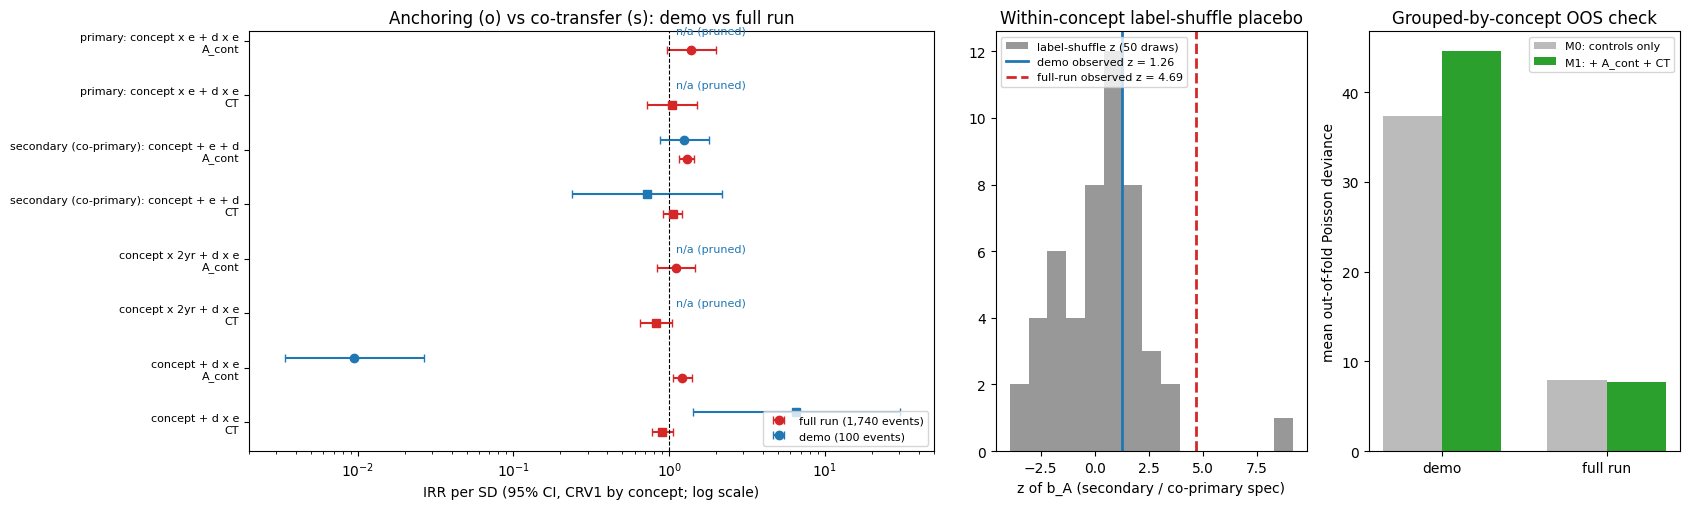

In [14]:
MODEL_KEYS = [("M1", "primary: concept x e + d x e"), ("M1_secondary", "secondary (co-primary): concept + e + d"),
              ("M1_coarse_cx2y", "concept x 2yr + d x e"), ("M1_c_plus_dxe", "concept + d x e")]
rows = []
for k, lab in MODEL_KEYS:
    for src, r, d in (("demo (100 events)", res[k], res.get("decision_primary" if k == "M1" else
                                                             "decision_secondary" if k == "M1_secondary" else f"decision_{k}")),
                      ("full run (1,740 events)", REF[k], None)):
        for v in ("A_cont", "CT"):
            if r is None:
                rows.append({"source": src, "spec": lab, "var": v, "n": None, "G": None, "irr_sd": np.nan,
                             "lo": np.nan, "hi": np.nan, "p_crv1": np.nan, "p_wild": np.nan})
                continue
            rows.append({"source": src, "spec": lab, "var": v, "n": r["n_retained"], "G": r["G"],
                         "irr_sd": r["irr_sd"][v], "lo": r["ci_irr_sd"][v][0], "hi": r["ci_irr_sd"][v][1],
                         "p_crv1": r["p"][v], "p_wild": (r.get("p_wild") or {}).get(v)})
cmp = pd.DataFrame(rows)
full_dec = {"M1": REF["decision_primary"]["reading"], "M1_secondary": REF["decision_secondary"]["reading"]}
print("Decisions  demo:", {k: (res.get("decision_primary" if k == "M1" else "decision_secondary" if k == "M1_secondary"
                                     else f"decision_{k}") or {}).get("reading", "n/a (not identified)")
                          for k, _ in MODEL_KEYS})
print("Decisions  full:", full_dec, "| fallback 3 (full):", REF["fallback3_thin_cells"]["triggered"])
print("OOS deviance diff M1-M0  demo: %.3f %s   full: %.3f %s" % (
    oos_res["deviance_diff_M1_minus_M0"], np.round(oos_res["deviance_diff_ci95_concept_bootstrap"], 3),
    REF["oos"]["deviance_diff_M1_minus_M0"], np.round(REF["oos"]["deviance_diff_ci95_concept_bootstrap"], 3)))
display_cols = ["source", "spec", "var", "n", "G", "irr_sd", "lo", "hi", "p_crv1", "p_wild"]
print(cmp[display_cols].to_string(index=False, float_format=lambda x: f"{x:.3g}"))

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2), gridspec_kw={"width_ratios": [2.2, 1, 1]})
ax = axes[0]
ypos, labels, seen = 0, [], set()
colors = {"demo (100 events)": "#1f77b4", "full run (1,740 events)": "#d62728"}
markers = {"A_cont": "o", "CT": "s"}
for k, lab in MODEL_KEYS:
    for v in ("A_cont", "CT"):
        for j, src in enumerate(colors):
            r = cmp[(cmp.spec == lab) & (cmp["var"] == v) & (cmp.source == src)].iloc[0]
            y = ypos + (0.18 if j == 0 else -0.18)
            if np.isfinite(r.irr_sd):
                ax.errorbar(r.irr_sd, y, xerr=[[r.irr_sd - r.lo], [r.hi - r.irr_sd]], fmt=markers[v],
                            color=colors[src], capsize=3, label=src if src not in seen else None)
                seen.add(src)
            else:
                ax.text(1.0, y, "  n/a (pruned)", va="center", fontsize=8, color=colors[src])
        labels.append(f"{lab}\n{v}")
        ypos -= 1
ax.axvline(1, color="k", lw=0.8, ls="--")
ax.set_xscale("log")
ax.set_xlim(0.002, 50)  # wide: degenerate (near-separated) demo estimates would otherwise fall off the axis
ax.set_yticks(range(0, ypos, -1))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("IRR per SD (95% CI, CRV1 by concept; log scale)")
ax.set_title("Anchoring (o) vs co-transfer (s): demo vs full run")
ax.legend(loc="lower right", fontsize=8)

ax = axes[1]
z_sec = ls["z_A_secondary"].dropna()
ax.hist(z_sec, bins=15, color="#7f7f7f", alpha=0.8, label=f"label-shuffle z ({len(z_sec)} draws)")
if summ.get("secondary"):
    ax.axvline(summ["secondary"]["z_A_obs"], color="#1f77b4", lw=2,
               label=f"demo observed z = {summ['secondary']['z_A_obs']:.2f}")
ax.axvline(REF["placebo_label_shuffle"]["secondary"]["z_A_obs"], color="#d62728", lw=2, ls="--",
           label=f"full-run observed z = {REF['placebo_label_shuffle']['secondary']['z_A_obs']:.2f}")
ax.set_xlabel("z of b_A (secondary / co-primary spec)")
ax.set_title("Within-concept label-shuffle placebo")
ax.legend(fontsize=8)

ax = axes[2]
vals = [(oos_res["mean_deviance_M0"], oos_res["mean_deviance_M1"]),
        (REF["oos"]["mean_deviance_M0"], REF["oos"]["mean_deviance_M1"])]
xx = np.arange(2)
ax.bar(xx - 0.18, [v[0] for v in vals], 0.36, label="M0: controls only", color="#bbbbbb")
ax.bar(xx + 0.18, [v[1] for v in vals], 0.36, label="M1: + A_cont + CT", color="#2ca02c")
ax.set_xticks(xx)
ax.set_xticklabels(["demo", "full run"])
ax.set_ylabel("mean out-of-fold Poisson deviance")
ax.set_title("Grouped-by-concept OOS check")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Reading the demo
* **Identification is the story.** On 100 events every concept×e cell of the primary spec is a singleton after pruning, so the primary model, its label-shuffle placebo and the `concept x 2yr` spec are *not identified*, and fallback 3 fires. The full run showed the same pattern in milder form: the primary spec kept only 26% of events and 77 clusters. That is why the pre-registration made the `concept + e + d` spec co-primary.
* **Co-primary spec.** The anchoring IRR/SD on the demo points the same way as the full-run estimate, but with ~70 retained events and ~30 clusters its CI is wide and the reading is NEITHER. In the full run (1,544 events, 140 clusters), A_cont IRR/SD = 1.30 [1.16, 1.45], Holm p 1e-5, wild p 0.001, which reads **GRAFTING**. Co-transfer is null in every spec.
* **`concept + d x e` on the demo is near-separated.** A handful of events carry each d×e cell, so the point estimates and the "negative anchoring" note are artefacts of the tiny sample. In the full run this spec gives GRAFTING (IRR/SD 1.22).
* **Out-of-sample check.** With 100 events split into 5 concept folds, adding A_cont and CT *overfits* (positive deviance difference). In the full run the difference is −0.23 [−0.54, 0.06]: a small predictive gain whose CI includes 0.
* **Full run.** To reproduce the paper's numbers, run the original `method.py` (stages 0–16) on the full hydrated OpenAlex corpus, or feed the full stage-6 event table (1,740 events) into the cells above.